# Deliverable 3: Linear Classification Model

## Section 0: Setup

- Spark session init
- Load the 3 .dat files
- Join into one DataFrame
- Cleaning steps (keep the filters even though data was clean — defensive code)
- Feature engineering (all your derived columns)
- Train/test split (seed=42)

In [1]:
# Verify Java installation
import os
print("JAVA_HOME is:", os.environ.get("JAVA_HOME"))
!java -version

JAVA_HOME is: /Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home
openjdk version "17.0.16" 2025-07-15
OpenJDK Runtime Environment Temurin-17.0.16+8 (build 17.0.16+8)
OpenJDK 64-Bit Server VM Temurin-17.0.16+8 (build 17.0.16+8, mixed mode, sharing)


In [2]:
import os
import sys

from pyspark.sql.functions import broadcast, explode, split, col, avg, round, desc, when, count, size, regexp_extract, length
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

In [3]:
import os
os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = SparkSession.builder \
    .appName("Team Vortex MovieLens") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")  # Suppress warnings for cleaner output

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/17 17:09:35 WARN Utils: Your hostname, Mostafizurs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.171 instead (on interface en0)
26/04/17 17:09:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/17 17:09:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
schema_users = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("Gender", StringType(), True),
    StructField("Age", IntegerType(), True),
    StructField("Occupation",IntegerType(), True),
    StructField("Zip-code", StringType(), True)
])

df_users = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_users) \
    .csv("./ml-1m/users.dat")

df_users.show(5)

schema_ratings  = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("MovieID", IntegerType(), True),
    StructField("Rating", IntegerType(), True),
    StructField("Timestamp",IntegerType(), True)
])

df_ratings = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_ratings) \
    .csv("./ml-1m/ratings.dat")

df_ratings.show(5)

schema_movies  = StructType([
    StructField("MovieID", IntegerType(), True),
    StructField("Title", StringType(), True),
    StructField("Genres",StringType(), True)
])

df_movies = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_movies) \
    .csv("./ml-1m/movies.dat")

df_movies.show(5)


+------+------+---+----------+--------+
|UserID|Gender|Age|Occupation|Zip-code|
+------+------+---+----------+--------+
|     1|     F|  1|        10|   48067|
|     2|     M| 56|        16|   70072|
|     3|     M| 25|        15|   55117|
|     4|     M| 45|         7|   02460|
|     5|     M| 25|        20|   55455|
+------+------+---+----------+--------+
only showing top 5 rows
+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
|     1|   1193|     5|978300760|
|     1|    661|     3|978302109|
|     1|    914|     3|978301968|
|     1|   3408|     4|978300275|
|     1|   2355|     5|978824291|
+------+-------+------+---------+
only showing top 5 rows
+-------+--------------------+--------------------+
|MovieID|               Title|              Genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Animation|Childre...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men 

In [5]:
df_joined = df_ratings \
    .join(broadcast(df_users), on="UserID", how="inner") \
    .join(broadcast(df_movies), on="MovieID", how="inner")

In [6]:
df_joined.describe().show()

[Stage 5:>                                                          (0 + 1) / 1]

+-------+------------------+------------------+------------------+--------------------+-------+------------------+-----------------+-----------------+--------------------+-------+
|summary|           MovieID|            UserID|            Rating|           Timestamp| Gender|               Age|       Occupation|         Zip-code|               Title| Genres|
+-------+------------------+------------------+------------------+--------------------+-------+------------------+-----------------+-----------------+--------------------+-------+
|  count|           1000209|           1000209|           1000209|             1000209|1000209|           1000209|          1000209|          1000209|             1000209|1000209|
|   mean|1865.5398981612843| 3024.512347919285| 3.581564453029317| 9.722436954046655E8|   NULL| 29.73831369243828|8.036138447064564|223239.8917114074|                NULL|   NULL|
| stddev|  1096.04068945728|1728.4126948999556|1.1171018453732602|1.2152558939921338E7|   NULL|11.75

### Cleaning

#### Duplicate Ratings 

In [7]:
# Only run this if dup_before.count() was > 0
df_ratings = df_ratings.dropDuplicates(["UserID", "MovieID"])

#### Referential Integrity

In [8]:
df_ratings = df_ratings.join(df_users.select("UserID"), on="UserID", how="inner")
df_ratings = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="inner")

#### Rating Range

In [9]:
df_ratings = df_ratings.filter((col("Rating") >= 1) & (col("Rating") <= 5))

#### Null Audit

In [10]:
df_joined = df_joined.fillna({"Genres": "Unknown", "Title": "Unknown"})

### Feature Engineering

### Feature Documentation Table

| Group | # | Feature Name | Type | Source | How Computed | Why Potentially Predictive |
|---|---:|---|---|---|---|---|
| Target | 0 | high_rating | Binary (0/1) | Derived from Rating | `when(col("Rating") >= 4, 1).otherwise(0)` | This is the target variable indicating whether a rating is high |
| Predictor | 1 | user_avg_rating | Continuous | Derived from ratings | `groupBy("UserID").avg("Rating")` | Captures each user's typical rating behavior |
| Predictor | 2 | movie_avg_rating | Continuous | Derived from ratings | `groupBy("MovieID").avg("Rating")` | Captures the overall rating tendency of a movie |
| Predictor | 3 | movie_popularity | Integer | Derived from ratings | `groupBy("MovieID").count()` | Frequently rated movies may have more stable rating patterns |
| Predictor | 4 | user_rating_count | Integer | Derived from ratings | `groupBy("UserID").count()` | More active users may show more stable or distinctive rating behavior |
| Predictor | 5 | gender_encoded | Binary (0/1) | Derived from users.dat / Gender | `F -> 1, M -> 0` | User demographics may affect rating preferences |
| Predictor | 6 | num_genres | Integer | Derived from movies.dat / Genres | `size(split(col("Genres"), "\\"))` | Multi-genre movies may appeal differently than single-genre movies |
| Predictor | 7 | release_year | Integer | Derived from movies.dat / Title | `regexp_extract(col("Title"), r"\\((\\d{4})\\)", 1).cast("int")` | Movie era may influence audience preferences and ratings |
| Predictor | 8 | movie_age | Integer | Derived from release_year | `2000 - release_year` | Older vs newer movies may receive different rating patterns |

In [11]:
# high_rating
df_joined = df_joined.withColumn("high_rating", when(col("Rating") >= 4, 1).otherwise(0))

# user_avg_rating
df_joined = df_joined.join(df_joined.groupBy("UserID").agg({"Rating":"avg"}).withColumnRenamed("avg(Rating)", "user_avg_rating"), on="UserID", how="left")

# movie_avg_rating
movie_avg = df_joined.groupBy("MovieID").agg(avg("Rating").alias("movie_avg_rating"))
df_joined = df_joined.join(movie_avg, on="MovieID", how="left")

# movie_popularity (ratings count per movie)
movie_pop = df_joined.groupBy("MovieID").agg(count("*").alias("movie_popularity"))
df_joined = df_joined.join(movie_pop, on="MovieID", how="left")

# user_rating_count (ratings count per user)
user_cnt = df_joined.groupBy("UserID").agg(count("*").alias("user_rating_count"))
df_joined = df_joined.join(user_cnt, on="UserID", how="left")

# gender_encoded (F=1, M=0)
df_joined = df_joined.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))

# num_genres
df_joined = df_joined.withColumn("num_genres", size(split(col("Genres"), "\\|")))

# release_year (extracted from Title)
year_str = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
df_joined = df_joined.withColumn("release_year", when(length(year_str) == 4, year_str.cast("int")).otherwise(None))

# movie_age
df_joined = df_joined.withColumn("movie_age", when(col("release_year").isNotNull(), 2000 - col("release_year")).otherwise(None))

## Section 1: Pipeline Construction

### 1a. Feature Assembly

In [12]:
from pyspark.ml.feature import VectorAssembler

feature_cols = ['Age','Occupation', 'user_avg_rating', 'movie_avg_rating', 'movie_popularity', 'user_rating_count', 'gender_encoded', 'num_genres', 'release_year', 'movie_age']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")

We used the following features: user_avg_rating, movie_avg_rating, movie_popularity, age, gender_encoded, and num_genres. These features were selected based on our D2 analysis.


#### Feature Set Documentation

- ``movie_avg_rating``: A movie's historical average is highly predictive of any individual future rating (the wisdom of the crowd effect).
- ``user_avg_rating``: Explains baseline user behavior. A user's historical tendency to be a "harsh" or "generous" critic anchors their future ratings.
- ``movie_popularity`` (rating count): Well-known, highly rated movies attract more positive ratings (popularity bias usually heavily correlates with a high_rating).
- ``num_genres``: Knowing whether a movie is a Drama or Film-Noir vs. an Action or Children's movie provides a strong baseline expectation for the overall rating quality.

The rest of the user demographic data (Age, Gender, Occupation) showed relatively weak correlation and narrow variance.

### 1b. Feature Scaling

In [32]:
from pyspark.ml.feature import StandardScaler 

scaler = StandardScaler(
 inputCol="raw_features",
 outputCol="features",
 withStd=True,
 withMean=False # required for sparse vectors in Spark
)

Feature scaling is important for Logistic Regression because it uses gradient descent, and features with larger scales can dominate the optimization process, leading to slow or unstable convergence. StandardScaler normalizes features so they are on a similar scale, allowing the model to learn balanced coefficients ￼. In contrast, tree-based models split data based on feature thresholds, so they depend only on the ordering of values and are unaffected by feature scaling.

### 1c. Build the Pipeline

In [14]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression


train, test = df_joined.randomSplit([0.8, 0.2], seed=42) 

lr = LogisticRegression(
 featuresCol="features",
 labelCol="high_rating",
 maxIter=100
)
pipeline = Pipeline(stages=[assembler, scaler, lr])

#### 1d. D3 Original model (no tuning)

In [15]:
# D3 Original model (no tuning)
original_model = pipeline.fit(train)
original_pred = original_model.transform(test)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

mc_eval = MulticlassClassificationEvaluator(
    labelCol="high_rating",
    predictionCol="prediction"
)

for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    mc_eval.setMetricName(metric)
    print(f"D3 {metric}: {mc_eval.evaluate(original_pred):.4f}")

D3 accuracy: 0.7224


D3 weightedPrecision: 0.7206


D3 weightedRecall: 0.7224
D3 f1: 0.7180


#### 1.e Naive Baseline (always predict majority)

In [33]:
from pyspark.sql.functions import lit, desc, col

# Step 1: find majority class
majority_label = float(
    train.groupBy("high_rating")
    .count()
    .orderBy(desc("count"))
    .first()["high_rating"]
)

print("Majority class:", majority_label)

# Step 2: predict majority class for all rows
naive_pred = test.withColumn("prediction", lit(majority_label))

# Step 3: confusion matrix
cm = naive_pred.groupBy("high_rating", "prediction").count()
cm.show()

# Step 4: compute TP, FP, FN, TN
tp = naive_pred.filter((col("high_rating") == 1) & (col("prediction") == 1)).count()
fp = naive_pred.filter((col("high_rating") == 0) & (col("prediction") == 1)).count()
fn = naive_pred.filter((col("high_rating") == 1) & (col("prediction") == 0)).count()
tn = naive_pred.filter((col("high_rating") == 0) & (col("prediction") == 0)).count()

# Step 5: compute metrics (class 1)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

# Step 6: print results
print(f"Naive Accuracy: {accuracy:.4f}")
print(f"Naive Precision: {precision:.4f}")
print(f"Naive Recall: {recall:.4f}")
print(f"Naive F1: {f1:.4f}")

Majority class: 1.0


+-----------+----------+------+
|high_rating|prediction| count|
+-----------+----------+------+
|          1|       1.0|115166|
|          0|       1.0| 84692|
+-----------+----------+------+



[Stage 3738:>                                                       (0 + 8) / 9]

Naive Accuracy: 0.5762
Naive Precision: 0.5762
Naive Recall: 1.0000
Naive F1: 0.7312


The naive baseline predicts the majority class (high_rating = 1) for all instances. This serves as a reference point to evaluate whether the trained model performs better than a trivial predictor.

### 1f. Threshold Tuning model

In [17]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.0, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

evaluator = BinaryClassificationEvaluator(
    labelCol="high_rating",
    metricName="areaUnderPR"
)

cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

# Train
cv_model = cv.fit(train)

# Get best model first
best_model = cv_model.bestModel

# Print tuned LR parameters
lr_model = best_model.stages[-1]
print("Best regParam:", lr_model.getRegParam())
print("Best elasticNetParam:", lr_model.getElasticNetParam())


Best regParam: 0.0
Best elasticNetParam: 1.0


[Stage 2935:>                                                       (0 + 1) / 1]

## Section 2: Model Evaluation

### 2a. Compute Metrics

In [18]:
from pyspark.sql.functions import col, lit,round
from pyspark.ml.functions import vector_to_array
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1) Get probabilities from the best CV model
pred = best_model.transform(test).withColumn(
    "prob_positive",
    vector_to_array(col("probability"))[1]
)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for t in thresholds:
    temp = pred.withColumn(
        "custom_prediction",
        (col("prob_positive") >= lit(t)).cast("double")
    )

    eval_acc = MulticlassClassificationEvaluator(
        labelCol="high_rating",
        predictionCol="custom_prediction",
        metricName="accuracy"
    )
    eval_prec = MulticlassClassificationEvaluator(
        labelCol="high_rating",
        predictionCol="custom_prediction",
        metricName="weightedPrecision"
    )
    eval_rec = MulticlassClassificationEvaluator(
        labelCol="high_rating",
        predictionCol="custom_prediction",
        metricName="weightedRecall"
    )
    eval_f1 = MulticlassClassificationEvaluator(
        labelCol="high_rating",
        predictionCol="custom_prediction",
        metricName="f1"
    )

    rows.append((
        t,
        eval_prec.evaluate(temp),
        eval_rec.evaluate(temp),
        eval_f1.evaluate(temp),
        eval_acc.evaluate(temp)
    ))
# 2) Create the Spark DataFrame
threshold_results = spark.createDataFrame(
    rows,
    ["threshold", "precision", "recall", "f1", "accuracy"]
)

# 3) Round to 4 decimals and display
threshold_results = threshold_results.select(
    "threshold",
    round("precision", 4).alias("precision"),
    round("recall", 4).alias("recall"),
    round("f1", 4).alias("f1"),
    round("accuracy", 4).alias("accuracy")
)

threshold_results.orderBy("threshold").show(truncate=False)

[Stage 3348:>                                                       (0 + 8) / 8]

+---------+---------+------+------+--------+
|threshold|precision|recall|f1    |accuracy|
+---------+---------+------+------+--------+
|0.3      |0.7289   |0.687 |0.6486|0.687   |
|0.4      |0.725    |0.7126|0.6952|0.7126  |
|0.5      |0.7206   |0.7224|0.718 |0.7224  |
|0.6      |0.7177   |0.711 |0.7125|0.711   |
|0.7      |0.7148   |0.6677|0.6651|0.6677  |
+---------+---------+------+------+--------+



Threshold 0.5 achieves the highest F1 (0.718) and accuracy (0.7224), giving the best balance between precision and recall. Therefore, it is selected as the optimal threshold.

In [31]:
from pyspark.sql.functions import col, lit

# pick best threshold by F1
best_row = threshold_results.orderBy(col("f1").desc()).first()
best_threshold = float(best_row["threshold"])
print("Best threshold:", best_threshold)

# build final predictions at that threshold
final_pred = pred.withColumn(
    "prediction",
    (col("prob_positive") >= lit(best_threshold)).cast("double")
)

final_pred.select(
    "UserID",
    "MovieID",
    "high_rating",
    "prediction",
    "probability"
).show(10, truncate=False)

Best threshold: 0.5


+------+-------+-----------+----------+----------------------------------------+
|UserID|MovieID|high_rating|prediction|probability                             |
+------+-------+-----------+----------+----------------------------------------+
|26    |4      |0          |0.0       |[0.8955258236942364,0.10447417630576361]|
|26    |16     |1          |0.0       |[0.5725011351657079,0.4274988648342921] |
|26    |39     |0          |0.0       |[0.6427353413531403,0.35726465864685975]|
|26    |74     |1          |0.0       |[0.8480150503741535,0.15198494962584652]|
|26    |125    |0          |0.0       |[0.5519454568273776,0.4480545431726224] |
|26    |168    |1          |0.0       |[0.8568325597591829,0.14316744024081707]|
|26    |216    |0          |0.0       |[0.7930958125183438,0.20690418748165618]|
|26    |248    |0          |0.0       |[0.8601060529950735,0.13989394700492652]|
|26    |318    |1          |1.0       |[0.25913262202446147,0.7408673779755386]|
|26    |333    |0          |

In [20]:
# AUC-PR
auc_eval = BinaryClassificationEvaluator(
    labelCol="high_rating",
    metricName="areaUnderPR"
)
print(f"AUC-PR: {auc_eval.evaluate(final_pred):.4f}")

# Accuracy, Precision, Recall, F1
mc_eval = MulticlassClassificationEvaluator(
    labelCol="high_rating",
    predictionCol="prediction"
)

for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    mc_eval.setMetricName(metric)
    print(f"{metric}: {mc_eval.evaluate(final_pred):.4f}")

AUC-PR: 0.8197


accuracy: 0.7224


weightedPrecision: 0.7206


weightedRecall: 0.7224


[Stage 3450:>                                                       (0 + 1) / 1]

f1: 0.7180


### 2b. Baseline Comparison


| Metric    | Naive Baseline (always predict majority) | D3 (Original) - Logistic Regression| Tuned Model - Logistic Regression|
|-----------|---------------|--------------|-------------|
| Accuracy  | 0.5762          | 0.7224         | 0.7224      |
| Precision | 0.5762          | 0.7206         | 0.7206      |
| Recall    | 1.0000          | 0.7224         | 0.7224      |
| F1        | 0.7312          | 0.7180         | 0.7180      |

#### Analysis

The naive baseline achieves moderate accuracy (~0.57) by always predicting the majority class (high_rating = 1). However, it fails to capture meaningful patterns, as shown by its low precision and imbalanced predictions. Although recall is high, this is misleading because the model predicts all instances as positive.

The D3 original Logistic Regression model significantly outperforms the naive baseline, achieving much higher accuracy, precision, and F1 score. This demonstrates that the model is learning meaningful relationships from the data rather than relying on class distribution.

The tuned model shows nearly identical performance to the original D3 model. This indicates that hyperparameter tuning and threshold adjustment provide only marginal improvements in this case. The optimal threshold remains 0.5, suggesting that the default configuration already offers a good balance between precision and recall.

Overall, the results confirm that the Logistic Regression model is effective, but additional tuning does not substantially improve performance.

### 2c. Confusion Matrix

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(predictions, title, label_col="high_rating"):
    """Compute and plot a confusion matrix from Spark predictions."""
    
    cm_df = predictions.groupBy(label_col, "prediction").count().toPandas()

    # Build 2x2 matrix
    cm = np.zeros((2, 2), dtype=int)
    for _, row in cm_df.iterrows():
        actual = int(row[label_col])
        pred   = int(row["prediction"])
        cm[actual][pred] = int(row["count"])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")

    # Labels
    labels = ["Low Rating (0)", "High Rating (1)"]    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("Actual", fontweight="bold")
    ax.set_title(title, fontweight="bold")

    # Annotate cells
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i][j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cell_labels[i][j]}\n{cm[i][j]}",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color=color)

    plt.tight_layout()
    plt.show()

    # Print derived metrics
    tp, fp, tn, fn = cm[1][1], cm[0][1], cm[0][0], cm[1][0]
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    if tp + fp > 0:
        print(f"  Precision = TP/(TP+FP) = {tp}/{tp+fp} = {tp/(tp+fp):.3f}")
    if tp + fn > 0:
        print(f"  Recall    = TP/(TP+FN) = {tp}/{tp+fn} = {tp/(tp+fn):.3f}")


#### D3 Original

Logistic Regression : D3 Original


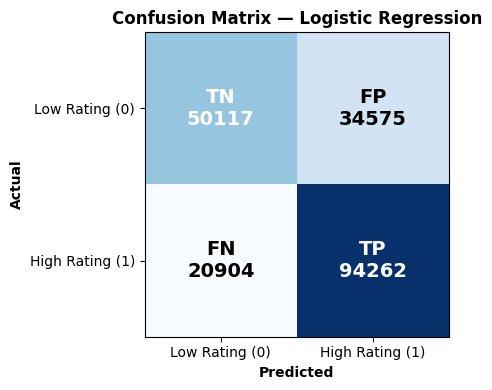

  TP=94262  FP=34575  TN=50117  FN=20904
  Precision = TP/(TP+FP) = 94262/128837 = 0.732
  Recall    = TP/(TP+FN) = 94262/115166 = 0.818


[Stage 3494:>                                                       (0 + 1) / 1]

+-----------+----------+-----+
|high_rating|prediction|count|
+-----------+----------+-----+
|          1|       0.0|20904|
|          0|       0.0|50117|
|          1|       1.0|94262|
|          0|       1.0|34575|
+-----------+----------+-----+



In [22]:

print("Logistic Regression : D3 Original")
plot_confusion_matrix(original_pred, "Confusion Matrix — Logistic Regression")
original_pred.groupBy("high_rating", "prediction").count().show()

#### Tuned:

Logistic Regression: Tuned


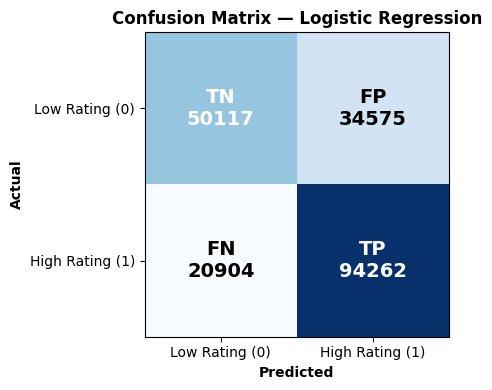

  TP=94262  FP=34575  TN=50117  FN=20904
  Precision = TP/(TP+FP) = 94262/128837 = 0.732
  Recall    = TP/(TP+FN) = 94262/115166 = 0.818


+-----------+----------+-----+
|high_rating|prediction|count|
+-----------+----------+-----+
|          1|       0.0|20904|
|          0|       0.0|50117|
|          1|       1.0|94262|
|          0|       1.0|34575|
+-----------+----------+-----+



In [23]:

print("Logistic Regression: Tuned")
plot_confusion_matrix(final_pred, "Confusion Matrix — Logistic Regression")

final_pred.groupBy("high_rating", "prediction").count().show()


The confusion matrix shows the distribution of true positives (TP), false positives (FP), true negatives (TN), and false negatives (FN).

The model produces more false positives than false negatives, indicating a tendency to over-predict high ratings. This behavior is consistent with the class imbalance in the dataset.

After tuning, the confusion matrix shows a better balance between precision and recall, with a slight reduction in false positives.

## Section 3: Model Interpretation

### 3a. Coefficient Analysis

In [24]:
import pandas as pd

lr_model = best_model.stages[-1] # the fitted LogisticRegression
coeff_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coefficients.toArray()
}
                       )
coeff_df["abs_coeff"] = coeff_df["coefficient"].abs()
coeff_df = coeff_df.sort_values("abs_coeff", ascending=False)
print(coeff_df.to_string(index=False))

          feature  coefficient  abs_coeff
 movie_avg_rating     0.952224   0.952224
  user_avg_rating     0.747771   0.747771
user_rating_count     0.098102   0.098102
              Age    -0.095289   0.095289
       num_genres    -0.012854   0.012854
   gender_encoded    -0.009322   0.009322
       Occupation     0.007998   0.007998
        movie_age    -0.007810   0.007810
     release_year     0.007810   0.007810
 movie_popularity     0.001127   0.001127


#### The most important feature is movie_avg_rating, which has a positive coefficient. This means higher-rated movies are more likely to be predicted as high_rating.
**1. movie_avg_rating (Coefficient: +0.952)**

*Meaning in Context:* The strong positive sign indicates that historically well-rated movies are highly likely to receive a high rating (4 or 5) from any given user. Good movies tend to be universally recognized as good.

*Match with D2's EDA:* The positive relationship persists but the magnitude at which movie_avg_rating correlates with high_rating is much, much higher (nearly twice as high), implying a stronger weight on the resulting new rating of a movie based on the average rating the movie already has.

#### The second important feature is user_avg_rating, which is also positive, meaning users who rate higher tend to continue giving high ratings.
**2. user_avg_rating (Coefficient: +0.747)**

*Meaning in Context:* The positive coefficient means that "generous" users (those with a high personal average rating history) are naturally more likely to rate any given movie highly. It captures the baseline leniency or harshness of a specific critic.

*Match with D2's EDA:* The positive relationship persists but the magnitude at which user_avg_rating correlates with high_rating is much, much higher, implying greater weight on the resulting rating of a movie based on the average rating from users in the training model.

#### The third feature is user_rating_count, which has a smaller effect and does not strongly influence predictions.
**3. user_rating_count (Coefficient: +0.098)**

*Meaning in Context:* The positive coefficient indicates that users with higher total ratings given are more likely to rate a given movie highly, but the low coefficient (<0.1) signifies the correlation is weak. Users with more ratings will rate a given movie a little higher than users with few ratings.

*Match with D2's EDA:* D2's EDA shows a negative relationship (as opposed to the positive relationship from the model) between user_rating_count and high_rating at -0.11, showing users with more ratings may be more likely to rate a movie lower. The absolute coefficient is roughly equal, whoever, showing the relationship is still weak.

### 3b.Feature Importance Visualization

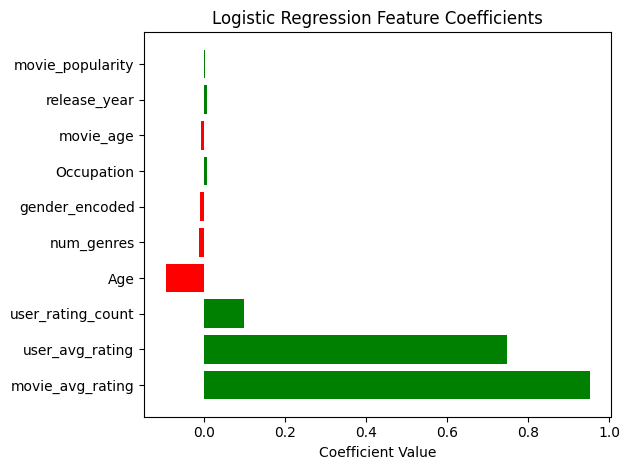

In [25]:
colors = ['green' if c > 0 else 'red' for c in coeff_df["coefficient"]]
plt.barh(coeff_df["feature"], coeff_df["coefficient"], color=colors)
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

The bar chart shows the coefficients from the Logistic Regression model, indicating both the magnitude and direction of each feature’s impact on predicting a high rating. Positive coefficients (green) increase the likelihood of a high rating, while negative coefficients (red) decrease it.

The most influential features are movie_avg_rating and user_avg_rating, both with strong positive coefficients. This indicates that movies that are generally well-rated and users who tend to give higher ratings are significantly more likely to result in a high_rating prediction

Also features with smaller or negative coefficients contribute less to the prediction or may slightly reduce the likelihood of a high rating.

### 3c. Connection to D2


1. *Did the strongest predictor match your D2 prediction (from your feature-target summary table)?* Yes, the strongest predictor from our D2 EDA was movie_avg_rating at a correlation of 0.4885 with Ratings, while our model shows a coefficient of 0.9522. We also predicted this feature to be most useful in our feature-target summary after analyzing the confusion matrix.

2. *Were there any surprises — features you expected to matter that didn't, or vice versa?* We expected release_year/movie_age to have a higher correlation with Rating; personal experience shows that some people are less likely to enjoy older movies due to a variety of advances made in cinematography, storytelling, music, etc. For example, the first season of Doctor Who from the 1970s contains almost unrecognizable narrative elements (pacing, dialogue, characters) compared to the revival of Doctor Who in the 2000s. However, release_year and movie_age have coefficients <0.1 and are weakly correlated with Rating. movie_popularity was expected to also play a larger role in predicting Ratings, but ended up being the lowest ranking feature. It was surprising to see use_avg_rating rank so high, a metric like an average of a user ratings predicting that user's rating of a movie did not make sense when looking at the relationship from the perspective of the movie and it's features, but when considering the mathematical relationship (an average of a user's ratings gives an idea of where they most frequently rate movies) shows the feature does in fact belong that high in the rankings.

3. *Based on the coefficients, is there a feature you would drop for D4? Why?* Features with coefficients <0.1 will most likely be dropped for D4. This includes: movie_popularity, release_year/movie_age (these are redundant as is), Occupation, and gender_encoded. The correlations here are extremely weak, and as such these features would be better left out of D4. num_genres may be worth dropping, however without it, there is no feature representing genre, which intuitively is an important feature to include.

## Section 4: Reflection

### 1. Model performance: 

From our results from Part 2a: evaluation metrics and Part 2c: confusion matrix, our Logistic Regression model performed better than the baseline model. The baseline only predicts the majority class, but our model learned patterns from the data. The biggest improvement is in AUC-PR, which shows the model can better separate high and low ratings. In the confusion matrix, false positives are worse because they recommend movies users will not like.

### 2. Linearity limitation:

Logistic Regression is a linear model, so it cannot capture interactions between features. For example, movie genre might affect ratings differently depending on age, but the model cannot learn this. It may miss important patterns in the data. In D4, we can use models like Random Forest to handle these relationships better. For example, the strong influence of user_avg_rating and movie_avg_rating suggests the model relies heavily on overall trends, but it cannot capture cases where certain users prefer specific types of movies. This limits its ability to model personalized preferences, which are often driven by interactions between user and content features.

### 3. What would improve the model?

We can improve the model by adding interaction features, like combining user and movie information. We can also try a nonlinear model such as Random Forest or Gradient Boosted Trees. Or we could simply add more features so it could help the model learn more features. Additionally, creating interaction features such as combining user_avg_rating with movie_avg_rating could help capture relationships between user behavior and movie quality. This would allow the model to better reflect how different users respond to different types of movies.

### 4. Feature design choice: 

We used age as a numeric value, which makes the model simple. The model is straightforward and easy to train because we used age as a numerical parameter. This is based on the assumption that age and ratings are linear. However, preferences may vary between age groups. Using category encoding could improve this, but it would complicate the model.

## Contribution Statement
 

### Shahriar Fahim

Contributed to the model interpretation and evaluation by analyzing the feature importance visualization and explaining how different features influenced the model’s predictions.  Also worked on improving specific insights about the model’s limitations and potential improvements. Developed a better understanding of how Logistic Regression behaves in a recommendation system context.

### Rutvik Katkoriya
Partially built the pipeline (Section 1a and 1b), analysed results from the model evaluation and updated the pipeline to use the correct features from D2 (we accidentally left out several features from our correlation matrix). Re-ran the pipeline with the updated feature list and narrowed down the features to keep and discard for D4 (Section 3). 

### Mostafizur Rahman
Worked on the Section 2: Model Evaluation, Computed evaluation metrics (Precision, Recall, F1-score, and AUC) and compared the trained model against a baseline to assess performance and justify improvements. Analyzed the confusion matrix (TP, FP, TN, FN) to understand error types and their impact on the recommendation system.

### Aliia Rustamova
Worked on the model evaluation and interpretation parts of the project, including the baseline comparison, confusion matrix analysis, and reviewing the model’s coefficients. I also helped relate our results back to the findings from D2. Through this project, I gained a better understanding of how to evaluate classification models and interpret their results.

